In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"dataset\BBC News Train.csv")
print(f'''
      Shape: {df.shape}
      Columns: {df.columns.tolist()}
      Category column values: {df['Category'].unique().tolist()}
''')


      Shape: (1490, 3)
      Columns: ['ArticleId', 'Text', 'Category']
      Category column values: ['business', 'tech', 'politics', 'sport', 'entertainment']



## Data filtering

In [3]:
tech_data = df[df.Category=='tech']
print(tech_data.shape)
tech_data.head()

(261, 3)


,ArticleId,Text,Category
3,1976,lifestyle governs mobile choice faster bett...,tech
19,1552,moving mobile improves golf swing a mobile pho...,tech
24,405,bt boosts its broadband packages british telec...,tech
26,702,peer-to-peer nets here to stay peer-to-peer ...,tech
30,1951,pompeii gets digital make-over the old-fashion...,tech


In [4]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
tech_data = tech_data.copy()

tech_data["num_sent"] = tech_data["Text"].apply(lambda x: len(sent_tokenize(x)))
filtered_data = tech_data[tech_data['Text'].str.contains('virus',case=False,na=False)]

filtered_data = filtered_data.copy()
filtered_data = filtered_data[(filtered_data["num_sent"] <= 15)]
filtered_data = filtered_data.drop_duplicates(subset=['Text'], keep='first')

filtered_data.to_csv(r'filtered_data.csv',index=False)

In [6]:
print(filtered_data.shape)
filtered_data.sort_values('num_sent')

(11, 4)


,ArticleId,Text,Category,num_sent
651,1615,microsoft seeking spyware trojan microsoft is ...,tech,10
550,964,junk e-mails on relentless rise spam traffic i...,tech,11
102,1680,security warning over fbi virus the us feder...,tech,12
914,574,how to smash a home computer an executive who ...,tech,12
509,2042,virus poses as christmas e-mail security firms...,tech,13
757,741,spam e-mails tempt net shoppers computer users...,tech,14
1489,538,santy worm makes unwelcome visit thousands of ...,tech,14
589,1604,joke e-mail virus tricks users a virus that di...,tech,15
908,793,fast moving phone viruses appear security firm...,tech,15
1232,1073,windows worm travels with tetris users are bei...,tech,15


## Sentence Spliting

In [7]:
sentences = []
source_ids = []

for idx, row in filtered_data.iterrows():
    article_id = row["ArticleId"]
    text = row["Text"]
    
    sents = sent_tokenize(text)
    
    for s in sents:
        s = s.strip()
        if len(s) > 0:
            sentences.append(s)
            source_ids.append(article_id)

In [8]:
sent_df = pd.DataFrame({
    "article_id": source_ids,
    "sentence": sentences
})

In [9]:
print(sent_df.shape)
sent_df.head(20)

(146, 2)


,article_id,sentence
0,1680,security warning over fbi virus the us feder...
1,1680,the e-mails show that they have come from an f...
2,1680,the messages warn that their internet use has ...
3,1680,an attachment in the e-mail contains the virus...
4,1680,the message asks recipients to click on the at...
5,1680,but rather than being a questionnaire the att...
6,1680,it is not clear what the virus does once it ha...
7,1680,users are warned never to open attachment from...
8,1680,recipients of this or similar solicitations sh...
9,1680,the bureau is investigating the phoney e-mails.


## Sentence preprocessing

In [10]:
import re
import unicodedata

In [11]:
clean_sentences = []
kept_source_ids = []

for idx, row in sent_df.iterrows():
    s = row['sentence']
    
    if not isinstance(s, str):
        continue
    
    s = s.strip()
    
    if len(s.split()) < 5:
        continue
    
    if not re.search(r"[A-Za-z]", s):
        continue
    
    if len(re.sub(r"[A-Za-z0-9]", "", s)) / max(1, len(s)) > 0.5:
        continue
    
    bad_patterns = [
        r"click here", r"share this", r"subscribe", r"read more",
        r"copyright", r"all rights reserved"
    ]
    if any(re.search(pat, s.lower()) for pat in bad_patterns):
        continue
    
    clean_sentences.append(s)
    kept_source_ids.append(row['article_id'])

In [12]:
assert len(clean_sentences) == len(kept_source_ids)

In [13]:
filtered_sent_df = pd.DataFrame({
    "article_id": kept_source_ids,
    "sentence": clean_sentences
    })

print("Before:", sent_df.shape)
print("After:", filtered_sent_df.shape)

Before: (146, 2)
After: (146, 2)


In [14]:
filtered_sent_df.head()

,article_id,sentence
0,1680,security warning over fbi virus the us feder...
1,1680,the e-mails show that they have come from an f...
2,1680,the messages warn that their internet use has ...
3,1680,an attachment in the e-mail contains the virus...
4,1680,the message asks recipients to click on the at...


In [15]:
def light_clean(text):
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[-_]{2,}', ' ', text)
    text = re.sub(r'([!?.,]){2,}', r'\1', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != "C")
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    return text

In [16]:
df_sent = filtered_sent_df.copy()

df_sent["clean_sentence"] = df_sent["sentence"].astype(str).apply(light_clean)

In [17]:
before = df_sent.shape[0]
df_sent = df_sent[df_sent["clean_sentence"].str.strip() != ""].reset_index(drop=True)
after = df_sent.shape[0]

final_df = df_sent[["article_id", "clean_sentence"]].rename(columns={"clean_sentence": "sentence"})

In [18]:
print(f"Sentences before cleaning: {before}")
print(f"Sentences after cleaning & removing empties: {after}")

Sentences before cleaning: 146
Sentences after cleaning & removing empties: 146


In [19]:
final_df.head()

,article_id,sentence
0,1680,security warning over fbi virus the us federal...
1,1680,the e-mails show that they have come from an f...
2,1680,the messages warn that their internet use has ...
3,1680,an attachment in the e-mail contains the virus...
4,1680,the message asks recipients to click on the at...


## Sentence Embedings

In [20]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [21]:
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64 

model = SentenceTransformer(MODEL_NAME)

In [22]:
sentences = final_df["sentence"].astype(str).tolist()
print("Number of sentences to encode:", len(sentences))

Number of sentences to encode: 146


In [23]:
embeddings = model.encode(sentences,
                batch_size=BATCH_SIZE,
                show_progress_bar=True,
                convert_to_numpy=True
            )

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embeddings shape: (146, 384)


In [24]:
sent_emb_df = final_df.reset_index(drop=True).copy()
sent_emb_df["emb_index"] = np.arange(len(sent_emb_df))

sent_emb_df.head()

,article_id,sentence,emb_index
0,1680,security warning over fbi virus the us federal...,0
1,1680,the e-mails show that they have come from an f...,1
2,1680,the messages warn that their internet use has ...,2
3,1680,an attachment in the e-mail contains the virus...,3
4,1680,the message asks recipients to click on the at...,4


## Dimensionality reduction

In [25]:
import umap

In [26]:
print("Original embedding shape:", embeddings.shape)

Original embedding shape: (146, 384)


In [27]:
n_components_cluster = 20
n_neighbors = 15

In [28]:
umap_cluster = umap.UMAP(
    n_components=n_components_cluster,
    n_neighbors=n_neighbors,
    metric='cosine',
    random_state=42
)

emb_reduced = umap_cluster.fit_transform(embeddings)
print("Reduced embedding shape:", emb_reduced.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (146, 20)


In [29]:
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

emb_2d = umap_2d.fit_transform(embeddings)
print("2D embedding shape:", emb_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embedding shape: (146, 2)


In [30]:
sent_emb_df["umap_x"] = emb_2d[:, 0]
sent_emb_df["umap_y"] = emb_2d[:, 1]

sent_emb_df.head()

,article_id,sentence,emb_index,umap_x,umap_y
0,1680,security warning over fbi virus the us federal...,0,10.449814,5.404735
1,1680,the e-mails show that they have come from an f...,1,10.719417,5.620338
2,1680,the messages warn that their internet use has ...,2,10.723829,5.400839
3,1680,an attachment in the e-mail contains the virus...,3,10.016548,5.445881
4,1680,the message asks recipients to click on the at...,4,9.990837,4.950269


## HDBSCAN Clustering

In [31]:
import hdbscan

In [32]:
MIN_CLUSTER_SIZE = 4    # minimum number of sentences to form a cluster (smaller -> more clusters)
MIN_SAMPLES = None
METRIC = "euclidean"

In [33]:

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric=METRIC,
    cluster_selection_method="eom",
    prediction_data=True,
    core_dist_n_jobs=4
)

In [34]:
labels = clusterer.fit_predict(emb_reduced)
probs = clusterer.probabilities_

sent_emb_df = sent_emb_df.copy().reset_index(drop=True)
sent_emb_df["hdb_cluster"] = labels
sent_emb_df["hdb_prob"] = probs

n_sentences = sent_emb_df.shape[0]
n_noise = int((sent_emb_df["hdb_cluster"] == -1).sum())
clusters_found = sorted([c for c in set(labels) if c != -1])
n_clusters = len(clusters_found)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [35]:
print(f"Total sentences clustered: {n_sentences}")
print(f"Noise sentences (label -1): {n_noise}")
print(f"Clusters found (excluding noise): {n_clusters}")
print("Cluster ids:", clusters_found)

print("\nCluster sizes (including noise -1):")
print(sent_emb_df["hdb_cluster"].value_counts().sort_index())

Total sentences clustered: 146
Noise sentences (label -1): 31
Clusters found (excluding noise): 7
Cluster ids: [0, 1, 2, 3, 4, 5, 6]

Cluster sizes (including noise -1):
-1    31
 0    14
 1    38
 2    26
 3    19
 4     7
 5     5
 6     6
Name: hdb_cluster, dtype: int64


In [36]:

# Optional: show top sentences per cluster by probability (quick sanity check)
print("\nTop representative sentences per cluster (highest membership probability):")
for c in clusters_found:
    subset = sent_emb_df[sent_emb_df["hdb_cluster"] == c].sort_values("hdb_prob", ascending=False).head(3)
    print(f"\nCluster {c} (n={len(subset)}):")
    for _, row in subset.iterrows():
        print(" -", row["sentence"][:200], " ... (prob:{:.2f})".format(row["hdb_prob"]))


Top representative sentences per cluster (highest membership probability):

Cluster 0 (n=3):
 - the cabir virus only affects high-end handsets running the symbian series 60 phone operating system.  ... (prob:1.00)
 - despite the warnings there are so far no reports of any phones being infected by the new variants of cabir.  ... (prob:1.00)
 - a mistake in the way the original cabir was written meant that even if it escaped from the laboratory the bug would only have been able to infect one phone at a time.  ... (prob:1.00)

Cluster 1 (n=3):
 - a spokeswoman said the two incidents appear to be unrelated.  ... (prob:1.00)
 - these were considered to be less critical however.  ... (prob:1.00)
 - mr palmer recalled the case of a couple who had hundreds of pictures of their baby s first three months on their computer but managed to reformat the hard drive and erase all the precious memories.  ... (prob:1.00)

Cluster 2 (n=3):
 - santy is not the first malicious program to use google to hel

In [37]:
sent_emb_df.to_csv(r"dataset\output\sentences_with_hdbscan_clusters.csv", index=False)

## Keywords for each cluster

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
TOP_N_KEYWORDS = 10
TOP_N_REP_SENTENCES = 5
CONFIDENCE_THRESHOLD = 0.60

In [40]:
df = sent_emb_df.copy().reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words="english", max_features=8000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df["sentence"].astype(str))
terms = np.array(vectorizer.get_feature_names_out())

clusters = sorted([c for c in df["hdb_cluster"].unique() if c != -1])

In [41]:
cluster_summaries = []

print("Found clusters (excluding noise):", clusters)
for c in clusters:
    high_conf_idx = df[(df["hdb_cluster"] == c) & (df["hdb_prob"] >= CONFIDENCE_THRESHOLD)].index.to_numpy()
    if high_conf_idx.size == 0:
        idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    else:
        idxs = high_conf_idx

    cluster_tfidf_sum = X_tfidf[idxs].sum(axis=0).A1
    top_term_indices = cluster_tfidf_sum.argsort()[::-1][:TOP_N_KEYWORDS]
    top_keywords = terms[top_term_indices].tolist()

    cluster_emb_idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    cluster_embs = emb_reduced[cluster_emb_idxs]
    if cluster_embs.shape[0] == 0:
        rep_sentences = []
    else:
        centroid = cluster_embs.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_embs, centroid).reshape(-1)
        top_local = sims.argsort()[::-1][:TOP_N_REP_SENTENCES]
        top_global_idxs = cluster_emb_idxs[top_local]
        rep_sentences = df.loc[top_global_idxs, ["sentence", "hdb_prob", "article_id"]].to_dict(orient="records")

    summary = {
        "cluster_id": c,
        "n_sentences": int((df["hdb_cluster"] == c).sum()),
        "top_keywords": top_keywords,
        "representative_sentences": rep_sentences
    }
    cluster_summaries.append(summary)

    print("\n=== Cluster", c, f"(n={summary['n_sentences']}) ===")
    print("Top keywords:", ", ".join(top_keywords[:10]))
    print("Representative sentences:")
    for rep in rep_sentences:
        prob = rep.get("hdb_prob", None)
        aid = rep.get("article_id", None)
        sent_preview = rep["sentence"]
        print(f" - (prob={prob:.2f}, article_id={aid}) {sent_preview}")

Found clusters (excluding noise): [0, 1, 2, 3, 4, 5, 6]

=== Cluster 0 (n=14) ===
Top keywords: phone, cabir, range, bluetooth, new, strains, phones, viruses, handset, symbian
Representative sentences:
 - (prob=0.97, article_id=793) the new strains of the cabir mobile phone virus use short-range radio technology to leap to any vulnerable phone as soon as it is in range.
 - (prob=1.00, article_id=793) the risk of being infected by cabir is low because users must give the malicious program permission to download on to their handset and then must manually install it.
 - (prob=1.00, article_id=793) a mistake in the way the original cabir was written meant that even if it escaped from the laboratory the bug would only have been able to infect one phone at a time.
 - (prob=0.88, article_id=793) however the new cabir strains have this mistake corrected and will spread via short range bluetooth technology to any vulnerable phone in range.
 - (prob=1.00, article_id=793) the cabir virus only aff

In [42]:
summary_rows = []
for s in cluster_summaries:
    summary_rows.append({
        "cluster_id": s["cluster_id"],
        "n_sentences": s["n_sentences"],
        "top_keywords": "; ".join(s["top_keywords"]),
        "representative_sentences": " || ".join([f"(p={r['hdb_prob']:.2f},aid={r['article_id']}) {r['sentence']}" for r in s["representative_sentences"]])
    })


In [43]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(r"dataset\output\cluster_summaries.csv", index=False)

## Cluster visualization

In [44]:
import matplotlib.pyplot as plt

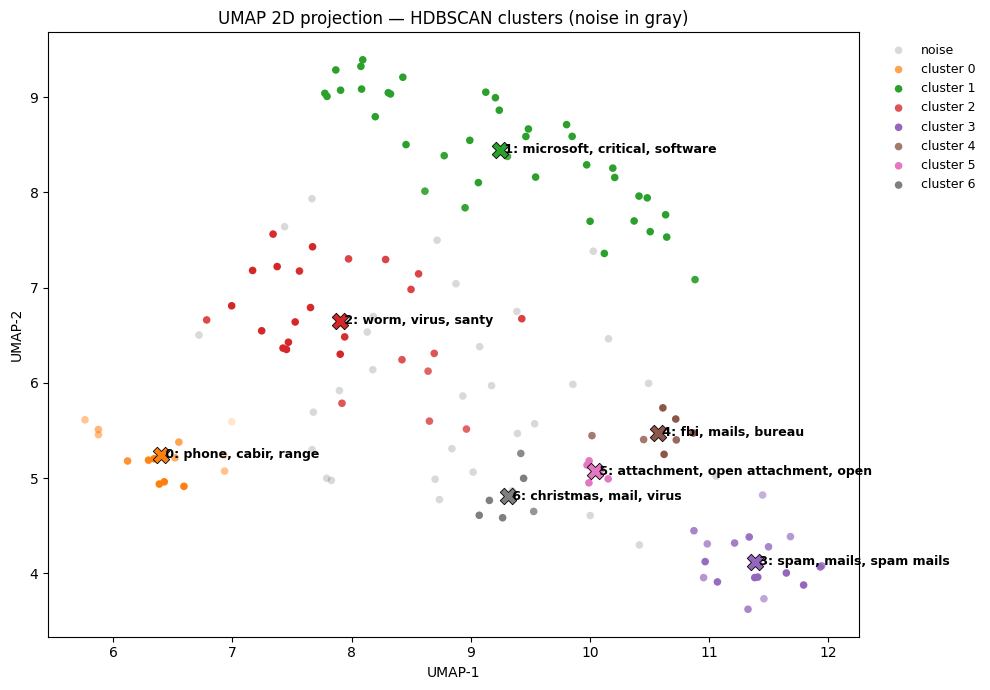

In [45]:
plt.rcParams["figure.dpi"] = 120
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7))

df = sent_emb_df.copy().reset_index(drop=True)
xs = df["umap_x"].values
ys = df["umap_y"].values
labels = df["hdb_cluster"].values
probs = df["hdb_prob"].values

# Determine unique clusters and colors
unique_clusters = sorted(df["hdb_cluster"].unique())
# assign gray for noise (-1)
palette = plt.get_cmap("tab10")
cluster_colors = {c: (0,0,0) if c == -1 else palette(i % 50) for i, c in enumerate(unique_clusters)}

alphas = np.clip((probs - 0.2) / 0.8, 0.15, 1.0)
for c in unique_clusters:
    mask = (labels == c)
    ax.scatter(xs[mask], ys[mask],
               s=30,
               alpha=alphas[mask],
               color=cluster_colors[c],
               label=("noise" if c == -1 else f"cluster {c}"),
               linewidths=0.2,
               edgecolors="none")

non_noise = [c for c in unique_clusters if c != -1]
centroids = {}
for c in non_noise:
    mask = (labels == c)
    if mask.sum() == 0:
        continue
    cx = xs[mask].mean()
    cy = ys[mask].mean()
    centroids[c] = (cx, cy)
    ax.scatter(cx, cy, s=140, marker="X", color=cluster_colors[c], edgecolor="k", linewidth=0.6)

if 'summary_df' in globals():
    for _, row in summary_df.iterrows():
        cid = row['cluster_id']
        if cid in centroids:
            cx, cy = centroids[cid]
            kw = row['top_keywords'].split(';')[:3] if isinstance(row['top_keywords'], str) else []
            ax.text(cx, cy, f" {cid}: " + ", ".join([k.strip() for k in kw]),
                    fontsize=9, fontweight='bold', verticalalignment='center')

ax.set_title("UMAP 2D projection — HDBSCAN clusters (noise in gray)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
